
# Cross-Department Model Summary

Summarize saved case/truck model metrics from each department's modeling suite outputs. This document shows the best test MAPE per department/target, how stackers compared to individual models, and the top models considered.


## Imports & Data Load

In [5]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


def load_results(models_dir=Path('models')):
    rows = []
    for dept_dir in sorted(models_dir.glob('dept*')):
        if not dept_dir.is_dir():
            continue
        dept = dept_dir.name.replace('dept', '')
        for target_key, target_label in [('case', 'cases'), ('truck', 'trucks')]:
            path = dept_dir / f'dept{dept}_{target_key}_model_results.csv'
            if not path.exists():
                continue
            df = pd.read_csv(path)
            # Ensure required columns exist
            if 'split' not in df:
                df['split'] = df['model'].apply(lambda x: 'test' if 'test' in x else 'val')
            if 'model_name' not in df:
                df['model_name'] = df['model'].str.replace('_val', '').str.replace('_test', '')
            df['dept'] = dept
            df['target'] = target_label
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

metrics_df = load_results()
print('Loaded rows:', len(metrics_df))
metrics_df.head()


Loaded rows: 206


,model,MAE,MAPE,RMSE,split,model_name,dept,target
0,naive,4.776429,0.098966,6.616376,val,naive,41,cases
1,seasonal7,4.038929,0.083718,5.722481,val,seasonal7,41,cases
2,ridge_val,3.525623,0.071139,4.947123,val,ridge,41,cases
3,ridge_test,4.047942,0.075911,5.835208,test,ridge,41,cases
4,elastic_val,3.401623,0.069538,4.776121,val,elastic,41,cases


## Best Test Models (Chosen)

In [6]:

if metrics_df.empty:
    print('No model result files found in models/dept*/')
else:
    test_df = metrics_df[metrics_df['split'] == 'test'].copy()

    def best_by_mask(mask):
        subset = test_df[mask(test_df)]
        if subset.empty:
            return pd.DataFrame(columns=['dept','target','model_name','MAPE','MAE','RMSE'])
        return (
            subset
            .sort_values(['dept','target','MAPE'])
            .groupby(['dept','target'], as_index=False)
            .first()[['dept','target','model_name','MAPE','MAE','RMSE']]
        )

    best_overall = best_by_mask(lambda df: df['split'].eq('test'))
    best_single = best_by_mask(lambda df: ~df['model_name'].str.contains('stack', case=False, na=False))
    best_stacker = best_by_mask(lambda df: df['model_name'].str.contains('stack', case=False, na=False))

    summary = best_overall.rename(columns={
        'model_name': 'chosen_model',
        'MAPE': 'chosen_MAPE',
        'MAE': 'chosen_MAE',
        'RMSE': 'chosen_RMSE'
    })

    summary = summary.merge(
        best_single.rename(columns={
            'model_name': 'best_single_model',
            'MAPE': 'best_single_MAPE',
            'MAE': 'best_single_MAE',
            'RMSE': 'best_single_RMSE'
        }),
        on=['dept','target'], how='left'
    )

    summary = summary.merge(
        best_stacker.rename(columns={
            'model_name': 'stacker_model',
            'MAPE': 'stacker_MAPE',
            'MAE': 'stacker_MAE',
            'RMSE': 'stacker_RMSE'
        }),
        on=['dept','target'], how='left'
    )

    if 'stacker_MAPE' in summary:
        summary['stacker_vs_single_MAPE_delta'] = summary['stacker_MAPE'] - summary['best_single_MAPE']
    summary = summary.sort_values(['dept','target'])
    display(summary)


,dept,target,chosen_model,chosen_MAPE,chosen_MAE,chosen_RMSE,best_single_model,best_single_MAPE,best_single_MAE,best_single_RMSE,stacker_model,stacker_MAPE,stacker_MAE,stacker_RMSE,stacker_vs_single_MAPE_delta
0,41,cases,rf,0.068236,3.568302,5.285053,rf,0.068236,3.568302,5.285053,NaN,NaN,NaN,NaN,NaN
1,41,trucks,hgb,0.046296,0.119519,0.252254,hgb,0.046296,0.119519,0.252254,NaN,NaN,NaN,NaN,NaN
2,6,cases,cat,0.069147,3.827758,5.821016,cat,0.069147,3.827758,5.821016,NaN,NaN,NaN,NaN,NaN
3,6,trucks,hgb,0.045748,0.117722,0.249761,hgb,0.045748,0.117722,0.249761,NaN,NaN,NaN,NaN,NaN
4,67,cases,cat,0.069187,3.866175,5.350469,cat,0.069187,3.866175,5.350469,NaN,NaN,NaN,NaN,NaN
5,67,trucks,rf,0.047936,0.118212,0.243385,rf,0.047936,0.118212,0.243385,NaN,NaN,NaN,NaN,NaN
6,9,cases,cat,0.068516,4.040412,6.575430,cat,0.068516,4.040412,6.575430,NaN,NaN,NaN,NaN,NaN
7,9,trucks,lgbm,0.047145,0.120831,0.249567,lgbm,0.047145,0.120831,0.249567,NaN,NaN,NaN,NaN,NaN
8,90,cases,et,0.071242,4.164912,5.741093,et,0.071242,4.164912,5.741093,NaN,NaN,NaN,NaN,NaN
9,90,trucks,hgb,0.046403,0.118027,0.248133,hgb,0.046403,0.118027,0.248133,NaN,NaN,NaN,NaN,NaN


## Top 3 Test Models per Department/Target

In [7]:

if metrics_df.empty:
    print('No model result files found in models/dept*/')
else:
    test_df = metrics_df[metrics_df['split'] == 'test'].copy()
    top3 = (
        test_df
        .sort_values(['dept','target','MAPE'])
        .groupby(['dept','target'])
        .head(3)
        .reset_index(drop=True)
    )
    display(top3[['dept','target','model_name','MAPE','MAE','RMSE']])


,dept,target,model_name,MAPE,MAE,RMSE
0,41,cases,rf,0.068236,3.568302,5.285053
1,41,cases,cat,0.068581,3.597299,5.308834
2,41,cases,et,0.068644,3.594494,5.308206
3,41,trucks,hgb,0.046296,0.119519,0.252254
4,41,trucks,cat,0.047136,0.117948,0.245655
5,41,trucks,rf,0.048144,0.118999,0.244219
6,6,cases,cat,0.069147,3.827758,5.821016
7,6,cases,hgb,0.069222,3.842289,5.850393
8,6,cases,et,0.069460,3.840095,5.812132
9,6,trucks,hgb,0.045748,0.117722,0.249761


## Visualization: Best Test MAPE by Department and Target

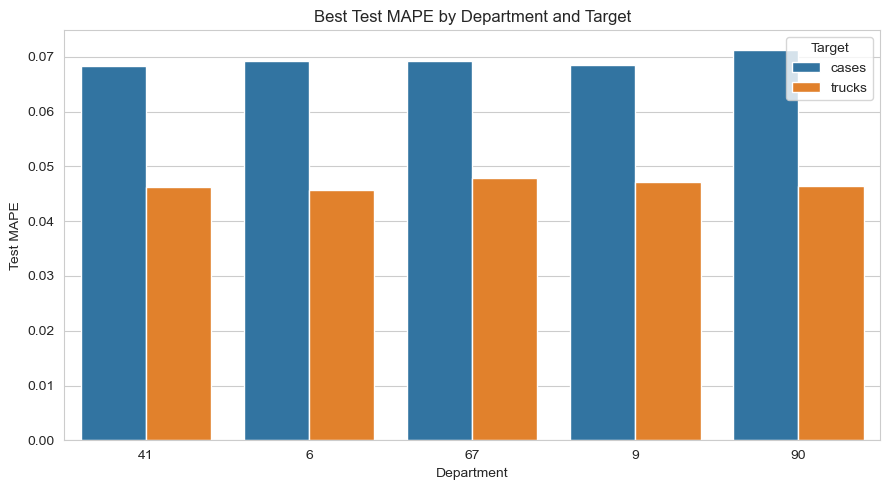

In [8]:

if metrics_df.empty:
    print('No model result files found in models/dept*/')
else:
    best_test = (
        metrics_df[metrics_df['split'] == 'test']
        .sort_values(['dept','target','MAPE'])
        .groupby(['dept','target'], as_index=False)
        .first()
    )
    plt.figure(figsize=(9,5))
    ax = sns.barplot(data=best_test, x='dept', y='MAPE', hue='target')
    plt.title('Best Test MAPE by Department and Target')
    plt.xlabel('Department')
    plt.ylabel('Test MAPE')
    plt.legend(title='Target')
    plt.tight_layout()
    plt.show()
